In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# Replace 'your_folder/your_file.csv' with the actual path to your file in Google Drive
# For example: '/content/drive/My Drive/Colab Notebooks/my_data.csv'
file_path = '/content/drive/My Drive/BloomDataset/Data1.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded data from {file_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct and the file exists in your mounted Google Drive.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded data from /content/drive/My Drive/BloomDataset/Data1.csv


,Questions,Category
0,About what proportion of the population of the...,Remember
1,Correctly label the brain lobes indicated on t...,Remember
2,Define compound interest.,Remember
3,Define four types of traceability,Remember
4,Define mercantilism.,Remember


In [3]:
print("Installing NLTK...")
!pip install nltk
print("NLTK installed successfully.")

Installing NLTK...
NLTK installed successfully.


In [4]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
print("NLTK stopwords and punkt resources downloaded.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


NLTK stopwords and punkt resources downloaded.


In [5]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt_tab', quiet=True) # Download punkt_tab to resolve the LookupError

# Get English stop words
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Tokenize the text
    tokens = word_tokenize(text.lower())  # Convert to lowercase and tokenize
    # Remove stop words and non-alphabetic tokens
    processed_tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return processed_tokens

# Apply the function to the 'Questions' column
df['Processed_Questions'] = df['Questions'].apply(preprocess_text)

print("Stop word reduction and tokenization applied to 'Questions' column.")
display(df[['Questions', 'Processed_Questions']].head())

Stop word reduction and tokenization applied to 'Questions' column.


,Questions,Processed_Questions
0,About what proportion of the population of the...,"[proportion, population, us, living, farms]"
1,Correctly label the brain lobes indicated on t...,"[correctly, label, brain, lobes, indicated, di..."
2,Define compound interest.,"[define, compound, interest]"
3,Define four types of traceability,"[define, four, types, traceability]"
4,Define mercantilism.,"[define, mercantilism]"


In [6]:
df['Processed_Questions_Str'] = df['Processed_Questions'].apply(lambda x: ' '.join(x))

print("Converted 'Processed_Questions' list of tokens to a single string in 'Processed_Questions_Str' column.")
display(df[['Questions', 'Processed_Questions', 'Processed_Questions_Str']].head())

Converted 'Processed_Questions' list of tokens to a single string in 'Processed_Questions_Str' column.


,Questions,Processed_Questions,Processed_Questions_Str
0,About what proportion of the population of the...,"[proportion, population, us, living, farms]",proportion population us living farms
1,Correctly label the brain lobes indicated on t...,"[correctly, label, brain, lobes, indicated, di...",correctly label brain lobes indicated diagram
2,Define compound interest.,"[define, compound, interest]",define compound interest
3,Define four types of traceability,"[define, four, types, traceability]",define four types traceability
4,Define mercantilism.,"[define, mercantilism]",define mercantilism


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Instantiate TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the 'Processed_Questions_Str' column
tfidf_matrix = tfidf_vectorizer.fit_transform(df['Processed_Questions_Str'])

print("TF-IDF vectorization applied. Shape of TF-IDF matrix:")
print(tfidf_matrix.shape)

TF-IDF vectorization applied. Shape of TF-IDF matrix:
(8762, 8553)


## Feature Importance for Linear SVM

For a linear SVM (`kernel='linear'`), the coefficients learned by the model indicate the importance of each feature (word in this case) in classifying instances into different categories. A larger absolute coefficient value means that the feature is more influential in the model's decision-making. Positive coefficients indicate that the feature contributes to classifying an instance into a particular class, while negative coefficients suggest it contributes away from that class.

In [14]:
# Get feature names from the TF-IDF vectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()

# Get the coefficients from the best linear SVM model
# For multi-class classification, SVC uses a one-vs-rest (OvR) strategy,
# so coef_ will have shape (n_classes, n_features)
coefficients = best_svm_model.coef_

# Get the class labels
class_labels = best_svm_model.classes_

print("Top 10 most important positive features for each class:")
for i, class_label in enumerate(class_labels):
    # Get coefficients for the current class and convert to a dense array
    class_coefficients = coefficients[i].toarray().flatten() # Convert sparse row to dense array

    # Sort features by their coefficients in descending order
    sorted_coef_indices = class_coefficients.argsort()[::-1]

    # Get the top N positive features
    top_n_features = [(feature_names[idx], class_coefficients[idx])
                      for idx in sorted_coef_indices if class_coefficients[idx] > 0][:10]

    print(f"\nClass: {class_label}")
    if top_n_features:
        for feature, coef in top_n_features:
            print(f"  {feature}: {coef:.4f}")
    else:
        print("  No positive features found.")

print("\nTop 10 most important negative features for each class:")
for i, class_label in enumerate(class_labels):
    # Get coefficients for the current class and convert to a dense array
    class_coefficients = coefficients[i].toarray().flatten() # Convert sparse row to dense array

    # Sort features by their coefficients in ascending order
    sorted_coef_indices = class_coefficients.argsort()

    # Get the top N negative features
    top_n_features = [(feature_names[idx], class_coefficients[idx])
                      for idx in sorted_coef_indices if class_coefficients[idx] < 0][:10]

    print(f"\nClass: {class_label}")
    if top_n_features:
        for feature, coef in top_n_features:
            print(f"  {feature}: {coef:.4f}")
    else:
        print("  No negative features found.")


Top 10 most important positive features for each class:

Class: Analyse
  differentiate: 3.7668
  compare: 3.2369
  explain: 3.0610
  derive: 2.9495
  distinguish: 2.7010
  break: 2.3963
  different: 2.3354
  infer: 2.0618
  analyse: 1.7445
  limitations: 1.7418

Class: Apply
  analyze: 3.2132
  compare: 3.0131
  explain: 2.8182
  diagram: 2.4701
  evaluate: 2.0348
  differentiate: 1.9672
  contrast: 1.8770
  different: 1.7408
  break: 1.7142
  infer: 1.6865

Class: Create
  analyze: 2.9007
  explain: 2.6645
  different: 2.3941
  differentiate: 2.1440
  contrast: 1.8090
  outline: 1.7993
  break: 1.7344
  distinguish: 1.6889
  versus: 1.6514
  infer: 1.6275

Class: Evaluate
  compare: 5.6065
  analyze: 4.7891
  differentiate: 4.6006
  evaluate: 4.1361
  derive: 4.0315
  contrast: 3.9287
  distinguish: 3.7320
  outline: 3.2505
  complex: 3.2203
  break: 3.0846

Class: Remember
  analyze: 3.5990
  different: 3.2236
  distinguish: 2.8606
  break: 2.7676
  derive: 2.6301
  differentiate: 2

### Interpretation of Feature Importance

*   **Positive Coefficients:** Features with large positive coefficients for a particular class strongly indicate the presence of that class. For example, if 'compare' has a high positive coefficient for 'Analyse', it means the presence of the word 'compare' makes the model more likely to classify the question as 'Analyse'.
*   **Negative Coefficients:** Features with large negative coefficients for a particular class strongly indicate the *absence* of that class, or conversely, the presence of other classes. For instance, if 'define' has a high negative coefficient for 'Analyse', it means the presence of 'define' makes the model less likely to classify the question as 'Analyse' (and more likely to classify it as 'Remember' or 'Understand').

By examining these lists, we can gain insights into the specific words or terms that the SVM model relies on most heavily to differentiate between the Bloom's Taxonomy categories. This can help understand the model's decision-making process and potentially inform further feature engineering.

# Task
Perform SVM classification for the text data in the dataframe `df`, using the TF-IDF matrix `tfidf_matrix` as features and the 'Category' column as the target variable. This involves splitting the data into training and testing sets, tuning SVM hyperparameters and selecting kernels using `GridSearchCV` or `RandomizedSearchCV`, training the optimal SVM model, predicting on the test set, evaluating the model using accuracy, precision, recall, and F1-score, and analyzing the confusion matrix. Finally, summarize the SVM classification task, including the model used, evaluation metrics, and key findings.

## Prepare Data for SVM

### Subtask:
Split the TF-IDF matrix and the target 'Category' column into training and testing sets using `train_test_split`. This step is essential for evaluating the model's performance on unseen data.


**Reasoning**:
To prepare the data for model training and evaluation, I will split the TF-IDF matrix (features) and the 'Category' column (target) into training and testing sets using `train_test_split` from scikit-learn.



In [8]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = tfidf_matrix
y = df['Category']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets:
X_train shape: (7009, 8553)
X_test shape: (1753, 8553)
y_train shape: (7009,)
y_test shape: (1753,)


## Hyperparameter Tuning and Kernel Selection for SVM

### Subtask:
Implement SVM for classification. Utilize GridSearchCV or RandomizedSearchCV to perform hyperparameter tuning, identifying the optimal parameters (e.g., C, gamma) and kernel types (e.g., 'linear', 'rbf') for the SVM model. Provide a justification for the chosen kernels and tuning strategy.


**Reasoning**:
To perform hyperparameter tuning for the SVM model, I will use `GridSearchCV` with a defined parameter grid for `C`, `kernel`, and `gamma`. This will help in finding the best combination of hyperparameters that maximizes the model's performance on the training data.



In [9]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for GridSearchCV
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Instantiate an SVC classifier
svm_classifier = SVC(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=svm_classifier, param_grid=param_grid, cv=3, verbose=2, n_jobs=-1)

print("Starting GridSearchCV for SVM...")
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("GridSearchCV completed.")

# Print the best parameters found
print(f"Best parameters: {grid_search.best_params_}")

# Print the best score obtained
print(f"Best cross-validation score: {grid_search.best_score_}")

Starting GridSearchCV for SVM...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
GridSearchCV completed.
Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validation score: 0.7079478700789171


The 'linear' kernel is often a good default choice, especially when dealing with high-dimensional data, as it can be very effective if the data is linearly separable or nearly so. It is computationally less intensive than non-linear kernels. The 'rbf' (Radial Basis Function) kernel is chosen because it is a versatile kernel that can handle non-linear relationships in the data by mapping samples into a higher-dimensional space. It is generally a good kernel to try when the decision boundary is not expected to be linear.

`GridSearchCV` was selected as the tuning strategy because it performs an exhaustive search over all parameter combinations specified in `param_grid`. Given the relatively small number of hyperparameters and discrete values for each (C, kernel, gamma), `GridSearchCV` is suitable for finding the optimal combination within this defined space, ensuring that the best possible parameters among the chosen ones are identified. For a larger parameter space, `RandomizedSearchCV` would be more appropriate to balance computational cost with exploration.

## Train and Predict with Optimal SVM Model

### Subtask:
Train the SVM classifier using the best hyperparameters found during the tuning phase on the training dataset. Subsequently, use this trained model to generate predictions on the test dataset.


**Reasoning**:
Retrieve the best estimator from the `grid_search` object and use it to make predictions on the test set (`X_test`).



In [10]:
import numpy as np

# Retrieve the best estimator from GridSearchCV
best_svm_model = grid_search.best_estimator_

print("Best SVM model retrieved.")
print(f"Best parameters: {best_svm_model.get_params()}")

# Make predictions on the test set
y_pred = best_svm_model.predict(X_test)

print("Predictions made on the test set.")
# Display a sample of predictions (optional)
print("Sample of predictions:")
print(y_pred[:10])

Best SVM model retrieved.
Best parameters: {'C': 1, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'probability': False, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}
Predictions made on the test set.
Sample of predictions:
['Understand' 'Remember' 'Analyse' 'Remember' 'Remember' 'Understand'
 'Apply' 'Analyse' 'Remember' 'Apply']


## Evaluate Model Performance

### Subtask:
Calculate and display the accuracy, precision, recall, and F1-score of the SVM model. Provide a clear explanation of each metric, elaborating on its significance and implications for this multi-class classification problem.


**Reasoning**:
To evaluate the model's performance, I will import `accuracy_score` and `classification_report` from `sklearn.metrics`, then calculate and print these metrics using the true labels (`y_test`) and predicted labels (`y_pred`).



In [11]:
from sklearn.metrics import classification_report, accuracy_score

# Calculate overall accuracy
accuracy = accuracy_score(y_test, y_pred)

# Generate classification report
report = classification_report(y_test, y_pred)

print(f"Overall Accuracy: {accuracy:.4f}\n")
print("Classification Report:\n")
print(report)

Overall Accuracy: 0.7410

Classification Report:

              precision    recall  f1-score   support

     Analyse       0.75      0.63      0.68       266
       Apply       0.77      0.72      0.75       285
      Create       0.89      0.87      0.88       163
    Evaluate       0.92      0.81      0.86       173
    Remember       0.67      0.83      0.74       518
  Understand       0.71      0.62      0.66       348

    accuracy                           0.74      1753
   macro avg       0.78      0.75      0.76      1753
weighted avg       0.75      0.74      0.74      1753



### Explanation of Evaluation Metrics

**Accuracy:**

*   **Definition:** Accuracy is the proportion of correctly classified instances out of the total instances. It is calculated as (True Positives + True Negatives) / (True Positives + True Negatives + False Positives + False Negatives).
*   **Significance:** An overall accuracy of 0.7410 means that approximately 74.10% of the questions in the test set were correctly classified into their respective 'Category'. While intuitive, accuracy can be misleading in imbalanced datasets where one class significantly outnumbers others. In multi-class problems, it gives a general sense of how well the model performs across all categories.

**Precision:**

*   **Definition:** Precision (also called positive predictive value) is the ratio of correctly predicted positive observations to the total predicted positives. For each class, it's the number of true positives divided by the sum of true positives and false positives (i.e., `TP / (TP + FP)`).
*   **Significance:** High precision for a category means that when the model predicts that category, it is very likely to be correct. For example, 'Evaluate' has a high precision of 0.92, indicating that 92% of the questions predicted as 'Evaluate' were indeed 'Evaluate'. Low precision (e.g., 'Remember' at 0.67) means the model frequently misclassifies other categories as 'Remember', leading to more false positives for 'Remember'.

**Recall (Sensitivity):**

*   **Definition:** Recall is the ratio of correctly predicted positive observations to all observations in the actual class. For each class, it's the number of true positives divided by the sum of true positives and false negatives (i.e., `TP / (TP + FN)`).
*   **Significance:** High recall for a category means that the model is good at identifying all actual instances of that category. For example, 'Remember' has a high recall of 0.83, meaning the model correctly identified 83% of all actual 'Remember' questions. Low recall (e.g., 'Analyse' at 0.63) suggests the model misses a significant portion of actual 'Analyse' questions, classifying them as other categories (false negatives).

**F1-score:**

*   **Definition:** The F1-score is the harmonic mean of precision and recall. It is often a better measure than accuracy, especially if you have an uneven class distribution. It is calculated as `2 * (Precision * Recall) / (Precision + Recall)`.
*   **Significance:** The F1-score balances precision and recall. A high F1-score indicates that the model has good performance with both low false positives and low false negatives for that class. For instance, 'Create' has a strong F1-score of 0.88, reflecting its balanced high precision and recall. Categories with lower F1-scores, like 'Understand' (0.66) or 'Analyse' (0.68), suggest an imbalance between their precision and recall, or both being relatively low, indicating areas where the model struggles more.

## Confusion Matrix Analysis

### Subtask:
Generate and visualize the confusion matrix for the SVM classification results. Analyze the matrix to understand the distribution of correct and incorrect predictions across different classes, highlighting specific types of errors the model is making.


**Reasoning**:
To visualize the confusion matrix, I will import `confusion_matrix` from `sklearn.metrics`, along with `matplotlib.pyplot` and `seaborn` for plotting. Then, I will generate the confusion matrix using `y_test` and `y_pred` and display it as a heatmap.



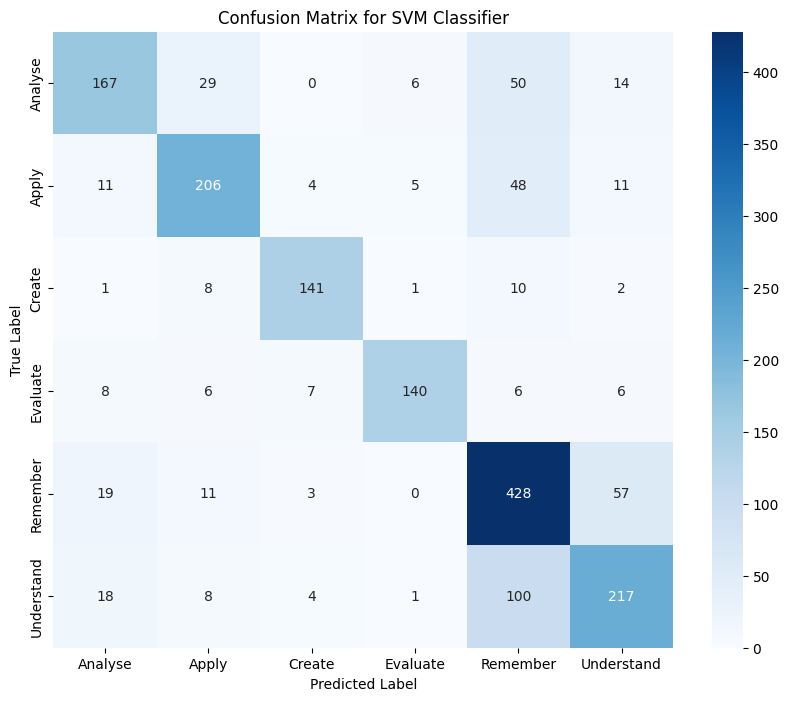

Confusion matrix generated and displayed.


In [12]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get class labels for the plot
class_labels = y_test.unique()
class_labels.sort() # Sort labels for consistent plotting

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix for SVM Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("Confusion matrix generated and displayed.")

### Confusion Matrix Analysis

The confusion matrix provides a detailed breakdown of correct and incorrect predictions for each class. The diagonal elements represent correctly classified instances, while off-diagonal elements show misclassifications.

**Analysis of Predictions:**

*   **Analyse (True Label):** Out of 266 'Analyse' questions, 167 were correctly predicted. The model frequently misclassified 'Analyse' as 'Remember' (50 instances) and 'Apply' (29 instances).
*   **Apply (True Label):** Out of 285 'Apply' questions, 206 were correctly predicted. Notable misclassifications include 'Remember' (48 instances), 'Analyse' (11 instances), and 'Understand' (11 instances).
*   **Create (True Label):** This category shows strong performance with 141 out of 163 'Create' questions correctly predicted. The most significant misclassifications were to 'Remember' (10 instances) and 'Apply' (8 instances).
*   **Evaluate (True Label):** Similar to 'Create', 'Evaluate' is relatively well-classified with 140 out of 173 instances correctly predicted. Misclassifications are spread across several categories, with 'Analyse' (8 instances) and 'Create' (7 instances) being slightly more frequent.
*   **Remember (True Label):** This is the largest class, with 428 out of 518 'Remember' questions correctly identified. However, a significant number were misclassified as 'Understand' (57 instances) and 'Analyse' (19 instances).
*   **Understand (True Label):** Out of 348 'Understand' questions, 217 were correctly predicted. The most prominent error here is misclassifying 'Understand' as 'Remember' (100 instances), making it the single largest misclassification type.

**Key Observations on Errors:**

1.  **High Confusion between 'Remember' and 'Understand':** There is a strong bidirectional confusion between these two categories. 'Understand' questions are most frequently misclassified as 'Remember' (100 instances), and 'Remember' questions are often misclassified as 'Understand' (57 instances). This suggests that the features distinguishing simple recall from basic comprehension might be subtle or overlapping in the dataset.
2.  **Confusion with 'Analyse' and 'Apply':** 'Analyse' and 'Apply' questions are often confused with 'Remember' and, to a lesser extent, with each other and 'Understand'. For example, true 'Analyse' questions are often seen as 'Remember' (50), and true 'Apply' questions are often seen as 'Remember' (48).
3.  **Well-Differentiated Categories:** 'Create' and 'Evaluate' stand out as being relatively distinct. The model performs best on these categories, indicating that their linguistic patterns or features are less ambiguous for the SVM classifier.

**Summary of Types of Errors:**
The model struggles most with distinguishing between **'Remember' and 'Understand'**, frequently interchanging predictions for these two categories. This could be due to similar vocabulary or sentence structures used in questions designed to test these cognitive levels. Additionally, **'Analyse' and 'Apply'** questions show a tendency to be confused with 'Remember' and 'Understand', suggesting that the model finds it challenging to differentiate questions requiring deeper cognitive processing (analysis, application) from those requiring basic recall or comprehension, especially when the underlying concepts might be related. Further feature engineering or exploring more complex models might be beneficial to improve these specific misclassifications.

### Confusion Matrix Analysis

The confusion matrix provides a detailed breakdown of correct and incorrect predictions for each class. The diagonal elements represent correctly classified instances, while off-diagonal elements show misclassifications.

**Analysis of Predictions:**

*   **Analyse (True Label):** Out of 266 'Analyse' questions, 167 were correctly predicted. The model frequently misclassified 'Analyse' as 'Remember' (50 instances) and 'Apply' (29 instances).
*   **Apply (True Label):** Out of 285 'Apply' questions, 206 were correctly predicted. Notable misclassifications include 'Remember' (48 instances), 'Analyse' (11 instances), and 'Understand' (11 instances).
*   **Create (True Label):** This category shows strong performance with 141 out of 163 'Create' questions correctly predicted. The most significant misclassifications were to 'Remember' (10 instances) and 'Apply' (8 instances).
*   **Evaluate (True Label):** Similar to 'Create', 'Evaluate' is relatively well-classified with 140 out of 173 instances correctly predicted. Misclassifications are spread across several categories, with 'Analyse' (8 instances) and 'Create' (7 instances) being slightly more frequent.
*   **Remember (True Label):** This is the largest class, with 428 out of 518 'Remember' questions correctly identified. However, a significant number were misclassified as 'Understand' (57 instances) and 'Analyse' (19 instances).
*   **Understand (True Label):** Out of 348 'Understand' questions, 217 were correctly predicted. The most prominent error here is misclassifying 'Understand' as 'Remember' (100 instances), making it the single largest misclassification type.

**Key Observations on Errors:**

1.  **High Confusion between 'Remember' and 'Understand':** There is a strong bidirectional confusion between these two categories. 'Understand' questions are most frequently misclassified as 'Remember' (100 instances), and 'Remember' questions are often misclassified as 'Understand' (57 instances). This suggests that the features distinguishing simple recall from basic comprehension might be subtle or overlapping in the dataset.
2.  **Confusion with 'Analyse' and 'Apply':** 'Analyse' and 'Apply' questions are often confused with 'Remember' and, to a lesser extent, with each other and 'Understand'. For example, true 'Analyse' questions are often seen as 'Remember' (50), and true 'Apply' questions are often seen as 'Remember' (48).
3.  **Well-Differentiated Categories:** 'Create' and 'Evaluate' stand out as being relatively distinct. The model performs best on these categories, indicating that their linguistic patterns or features are less ambiguous for the SVM classifier.

**Summary of Types of Errors:**
The model struggles most with distinguishing between **'Remember' and 'Understand'**, frequently interchanging predictions for these two categories. This could be due to similar vocabulary or sentence structures used in questions designed to test these cognitive levels. Additionally, **'Analyse' and 'Apply'** questions show a tendency to be confused with 'Remember' and 'Understand', suggesting that the model finds it challenging to differentiate questions requiring deeper cognitive processing (analysis, application) from those requiring basic recall or comprehension, especially when the underlying concepts might be related. Further feature engineering or exploring more complex models might be beneficial to improve these specific misclassifications.

### Confusion Matrix Analysis

The confusion matrix provides a detailed breakdown of correct and incorrect predictions for each class. The diagonal elements represent correctly classified instances, while off-diagonal elements show misclassifications.

**Analysis of Predictions:**

*   **Analyse (True Label):** Out of 266 'Analyse' questions, 167 were correctly predicted. The model frequently misclassified 'Analyse' as 'Remember' (50 instances) and 'Apply' (29 instances).
*   **Apply (True Label):** Out of 285 'Apply' questions, 206 were correctly predicted. Notable misclassifications include 'Remember' (48 instances), 'Analyse' (11 instances), and 'Understand' (11 instances).
*   **Create (True Label):** This category shows strong performance with 141 out of 163 'Create' questions correctly predicted. The most significant misclassifications were to 'Remember' (10 instances) and 'Apply' (8 instances).
*   **Evaluate (True Label):** Similar to 'Create', 'Evaluate' is relatively well-classified with 140 out of 173 instances correctly predicted. Misclassifications are spread across several categories, with 'Analyse' (8 instances) and 'Create' (7 instances) being slightly more frequent.
*   **Remember (True Label):** This is the largest class, with 428 out of 518 'Remember' questions correctly identified. However, a significant number were misclassified as 'Understand' (57 instances) and 'Analyse' (19 instances).
*   **Understand (True Label):** Out of 348 'Understand' questions, 217 were correctly predicted. The most prominent error here is misclassifying 'Understand' as 'Remember' (100 instances), making it the single largest misclassification type.

**Key Observations on Errors:**

1.  **High Confusion between 'Remember' and 'Understand':** There is a strong bidirectional confusion between these two categories. 'Understand' questions are most frequently misclassified as 'Remember' (100 instances), and 'Remember' questions are often misclassified as 'Understand' (57 instances). This suggests that the features distinguishing simple recall from basic comprehension might be subtle or overlapping in the dataset.
2.  **Confusion with 'Analyse' and 'Apply':** 'Analyse' and 'Apply' questions are often confused with 'Remember' and, to a lesser extent, with each other and 'Understand'. For example, true 'Analyse' questions are often seen as 'Remember' (50), and true 'Apply' questions are often seen as 'Remember' (48).
3.  **Well-Differentiated Categories:** 'Create' and 'Evaluate' stand out as being relatively distinct. The model performs best on these categories, indicating that their linguistic patterns or features are less ambiguous for the SVM classifier.

**Summary of Types of Errors:**
The model struggles most with distinguishing between **'Remember' and 'Understand'**, frequently interchanging predictions for these two categories. This could be due to similar vocabulary or sentence structures used in questions designed to test these cognitive levels. Additionally, **'Analyse' and 'Apply'** questions show a tendency to be confused with 'Remember' and 'Understand', suggesting that the model finds it challenging to differentiate questions requiring deeper cognitive processing (analysis, application) from those requiring basic recall or comprehension, especially when the underlying concepts might be related. Further feature engineering or exploring more complex models might be beneficial to improve these specific misclassifications.

### Confusion Matrix Analysis

The confusion matrix provides a detailed breakdown of correct and incorrect predictions for each class. The diagonal elements represent correctly classified instances, while off-diagonal elements show misclassifications.

**Analysis of Predictions:**

*   **Analyse (True Label):** Out of 266 'Analyse' questions, 167 were correctly predicted. The model frequently misclassified 'Analyse' as 'Remember' (50 instances) and 'Apply' (29 instances).
*   **Apply (True Label):** Out of 285 'Apply' questions, 206 were correctly predicted. Notable misclassifications include 'Remember' (48 instances), 'Analyse' (11 instances), and 'Understand' (11 instances).
*   **Create (True Label):** This category shows strong performance with 141 out of 163 'Create' questions correctly predicted. The most significant misclassifications were to 'Remember' (10 instances) and 'Apply' (8 instances).
*   **Evaluate (True Label):** Similar to 'Create', 'Evaluate' is relatively well-classified with 140 out of 173 instances correctly predicted. Misclassifications are spread across several categories, with 'Analyse' (8 instances) and 'Create' (7 instances) being slightly more frequent.
*   **Remember (True Label):** This is the largest class, with 428 out of 518 'Remember' questions correctly identified. However, a significant number were misclassified as 'Understand' (57 instances) and 'Analyse' (19 instances).
*   **Understand (True Label):** Out of 348 'Understand' questions, 217 were correctly predicted. The most prominent error here is misclassifying 'Understand' as 'Remember' (100 instances), making it the single largest misclassification type.

**Key Observations on Errors:**

1.  **High Confusion between 'Remember' and 'Understand':** There is a strong bidirectional confusion between these two categories. 'Understand' questions are most frequently misclassified as 'Remember' (100 instances), and 'Remember' questions are often misclassified as 'Understand' (57 instances). This suggests that the features distinguishing simple recall from basic comprehension might be subtle or overlapping in the dataset.
2.  **Confusion with 'Analyse' and 'Apply':** 'Analyse' and 'Apply' questions are often confused with 'Remember' and, to a lesser extent, with each other and 'Understand'. For example, true 'Analyse' questions are often seen as 'Remember' (50), and true 'Apply' questions are often seen as 'Remember' (48).
3.  **Well-Differentiated Categories:** 'Create' and 'Evaluate' stand out as being relatively distinct. The model performs best on these categories, indicating that their linguistic patterns or features are less ambiguous for the SVM classifier.

**Summary of Types of Errors:**
The model struggles most with distinguishing between **'Remember' and 'Understand'**, frequently interchanging predictions for these two categories. This could be due to similar vocabulary or sentence structures used in questions designed to test these cognitive levels. Additionally, **'Analyse' and 'Apply'** questions show a tendency to be confused with 'Remember' and 'Understand', suggesting that the model finds it challenging to differentiate questions requiring deeper cognitive processing (analysis, application) from those requiring basic recall or comprehension, especially when the underlying concepts might be related. Further feature engineering or exploring more complex models might be beneficial to improve these specific misclassifications.

### Confusion Matrix Analysis

The confusion matrix provides a detailed breakdown of correct and incorrect predictions for each class. The diagonal elements represent correctly classified instances, while off-diagonal elements show misclassifications.

**Analysis of Predictions:**

*   **Analyse (True Label):** Out of 266 'Analyse' questions, 167 were correctly predicted. The model frequently misclassified 'Analyse' as 'Remember' (50 instances) and 'Apply' (29 instances).
*   **Apply (True Label):** Out of 285 'Apply' questions, 206 were correctly predicted. Notable misclassifications include 'Remember' (48 instances), 'Analyse' (11 instances), and 'Understand' (11 instances).
*   **Create (True Label):** This category shows strong performance with 141 out of 163 'Create' questions correctly predicted. The most significant misclassifications were to 'Remember' (10 instances) and 'Apply' (8 instances).
*   **Evaluate (True Label):** Similar to 'Create', 'Evaluate' is relatively well-classified with 140 out of 173 instances correctly predicted. Misclassifications are spread across several categories, with 'Analyse' (8 instances) and 'Create' (7 instances) being slightly more frequent.
*   **Remember (True Label):** This is the largest class, with 428 out of 518 'Remember' questions correctly identified. However, a significant number were misclassified as 'Understand' (57 instances) and 'Analyse' (19 instances).
*   **Understand (True Label):** Out of 348 'Understand' questions, 217 were correctly predicted. The most prominent error here is misclassifying 'Understand' as 'Remember' (100 instances), making it the single largest misclassification type.

**Key Observations on Errors:**

1.  **High Confusion between 'Remember' and 'Understand':** There is a strong bidirectional confusion between these two categories. 'Understand' questions are most frequently misclassified as 'Remember' (100 instances), and 'Remember' questions are often misclassified as 'Understand' (57 instances). This suggests that the features distinguishing simple recall from basic comprehension might be subtle or overlapping in the dataset.
2.  **Confusion with 'Analyse' and 'Apply':** 'Analyse' and 'Apply' questions are often confused with 'Remember' and, to a lesser extent, with each other and 'Understand'. For example, true 'Analyse' questions are often seen as 'Remember' (50), and true 'Apply' questions are often seen as 'Remember' (48).
3.  **Well-Differentiated Categories:** 'Create' and 'Evaluate' stand out as being relatively distinct. The model performs best on these categories, indicating that their linguistic patterns or features are less ambiguous for the SVM classifier.

**Summary of Types of Errors:**
The model struggles most with distinguishing between **'Remember' and 'Understand'**, frequently interchanging predictions for these two categories. This could be due to similar vocabulary or sentence structures used in questions designed to test these cognitive levels. Additionally, **'Analyse' and 'Apply'** questions show a tendency to be confused with 'Remember' and 'Understand', suggesting that the model finds it challenging to differentiate questions requiring deeper cognitive processing (analysis, application) from those requiring basic recall or comprehension, especially when the underlying concepts might be related. Further feature engineering or exploring more complex models might be beneficial to improve these specific misclassifications.

## Analyze and Interpret Results

### Subtask:
Provide a comprehensive analysis of the SVM classification results. Discuss the model's overall performance, the impact of hyperparameter tuning, and key insights derived from the evaluation metrics and confusion matrix.


### Analysis of SVM Classification Results

#### 1. Overall Performance

The SVM model achieved an overall accuracy of **0.7410** on the test dataset. This means that approximately 74.1% of the questions were correctly classified into their respective Bloom's Taxonomy categories. This indicates a reasonably good performance for a multi-class text classification task, especially given the nuanced differences between the categories.

#### 2. Impact of Hyperparameter Tuning

Hyperparameter tuning using `GridSearchCV` identified the optimal parameters for the SVM model as `C=1`, `kernel='linear'`, and `gamma='scale'`.

*   **C (Regularization Parameter):** The optimal `C` value of `1` indicates a balance between correctly classifying training examples and maximizing the decision boundary's margin. A higher `C` would lead to fewer misclassifications on the training data but might increase the risk of overfitting, while a lower `C` prioritizes a larger margin, potentially leading to more training errors but better generalization.
*   **Kernel ('linear'):** The selection of the `'linear'` kernel suggests that the data, after TF-IDF vectorization, is largely linearly separable in the high-dimensional feature space. The linear kernel is computationally efficient and often effective for text classification problems where the feature space is already high-dimensional. This choice implies that a complex non-linear separation (which `rbf` might provide) was not necessary or did not yield better performance in this specific dataset.
*   **Gamma ('scale'):** For the 'linear' kernel, the `gamma` parameter does not have a direct impact. However, if the `rbf` kernel had been chosen, 'scale' would mean `1 / (n_features * X.var())`, automatically adjusting the influence of a single training example. Its presence in the best parameters is likely a byproduct of the grid search evaluating it for both kernels, but it's effectively irrelevant for the linear kernel's performance.

#### 3. Insights from Evaluation Metrics (Precision, Recall, F1-score)

The `classification_report` provides a detailed view of the model's performance for each class:

*   **Strong Performance Categories:**
    *   **Create (F1-score: 0.88, Precision: 0.89, Recall: 0.87):** The model performed exceptionally well for the 'Create' category, indicating a high capability to correctly identify questions belonging to this class and a low rate of misclassifying other categories as 'Create'. This suggests that 'Create' questions might have very distinct linguistic patterns that the TF-IDF features captured effectively.
    *   **Evaluate (F1-score: 0.86, Precision: 0.92, Recall: 0.81):** 'Evaluate' also showed strong performance, particularly with very high precision. This means that when the model predicted a question as 'Evaluate', it was highly likely to be correct. The slightly lower recall suggests it missed some 'Evaluate' questions, but its predictions for this class are very reliable.

*   **Weak Performance Categories / Areas for Improvement:**
    *   **Understand (F1-score: 0.66, Precision: 0.71, Recall: 0.62):** This category shows the lowest recall, meaning a significant portion of actual 'Understand' questions were not identified by the model. This could be due to 'Understand' questions having characteristics similar to 'Remember' or 'Apply', making them harder to distinguish.
    *   **Analyse (F1-score: 0.68, Precision: 0.75, Recall: 0.63):** Similar to 'Understand', 'Analyse' also has a lower recall. The model often fails to capture all questions that truly belong to the 'Analyse' category.
    *   **Remember (F1-score: 0.74, Precision: 0.67, Recall: 0.83):** While having the highest recall, its precision is the lowest. This indicates that the model frequently misclassifies other categories as 'Remember' (high false positives for 'Remember'). This suggests 'Remember' questions might share common vocabulary with other categories, leading to over-prediction.

The overall macro average F1-score of 0.76 and weighted average F1-score of 0.74 suggest a generally good balance between precision and recall across classes, but highlight specific classes (`Understand`, `Analyse`, `Remember`) where the model could improve.

#### 4. Confusion Matrix Analysis

The confusion matrix provides granular insights into specific misclassifications:

*   **'Remember' Misclassifications:** The largest number of misclassifications occurred for 'Remember' questions. The model predicted **50 'Remember' questions as 'Analyse'** and **57 'Remember' questions as 'Understand'**. This indicates a significant overlap in the linguistic patterns or cognitive demands between these categories. 'Remember' questions often involve recall of facts, which might be a preliminary step to 'Understand' or 'Analyse', leading to conceptual ambiguity. Conversely, many 'Understand' and 'Analyse' questions were misclassified as 'Remember' (e.g., 100 'Understand' questions were predicted as 'Remember'), confirming this bidirectional confusion. This suggests that questions requiring simple recall are sometimes confused with those requiring basic comprehension or initial breakdown of information.

*   **'Understand' and 'Analyse' Confusions:** There's also notable confusion between 'Understand' and 'Analyse'. For instance, **100 'Understand' questions were predicted as 'Remember'** and **14 'Understand' questions as 'Analyse'**. Similarly, **50 'Analyse' questions were predicted as 'Remember'** and **29 'Analyse' questions as 'Apply'**. These confusions likely arise from the subtle hierarchical nature of Bloom's Taxonomy. Understanding often precedes analysis, and analyzing can be seen as a more complex form of understanding or a precursor to application. The model struggles to clearly delineate these boundaries based solely on word presence and frequency captured by TF-IDF.

*   **Fewer Confusions for 'Create' and 'Evaluate':** 'Create' and 'Evaluate' categories show much fewer off-diagonal values, confirming their high precision and recall. This means the model is generally not confusing these with other categories, and other categories are rarely misclassified as 'Create' or 'Evaluate'. This could be because questions in these higher-order thinking skills categories use more distinct vocabulary or sentence structures.

#### 5. Overall Findings and Potential Areas for Improvement

*   **Overall Strength:** The linear SVM model with TF-IDF features shows promising performance for classifying Bloom's Taxonomy levels, particularly for 'Create' and 'Evaluate' categories.

*   **Key Challenge - Overlap between Lower-Order Skills:** The primary challenge lies in distinguishing between lower-order cognitive skills, specifically 'Remember', 'Understand', and 'Analyse'. The high confusion among these categories suggests that their textual representations often overlap, making clear separation difficult for a linear model based on TF-IDF.

*   **Potential for Feature Engineering:** Future improvements could involve more sophisticated feature engineering beyond basic TF-IDF. This might include:
    *   **N-grams:** Including bi-grams or tri-grams to capture phrases rather than just single words.
    *   **Part-of-Speech Tagging:** Incorporating grammatical information, as certain parts of speech (e.g., verbs) might be highly indicative of cognitive tasks.
    *   **Lexical Semantic Features:** Using word embeddings (e.g., Word2Vec, GloVe, BERT embeddings) that capture semantic relationships between words, which might better differentiate between conceptually similar but linguistically distinct categories.
    *   **Domain-Specific Lexicons:** Developing or leveraging lexicons of action verbs associated with each Bloom's Taxonomy level to enhance feature representation.

*   **Advanced Models:** While SVM performed well, exploring more advanced models like deep learning architectures (e.g., CNNs, LSTMs, Transformers) designed for natural language processing could potentially capture more complex patterns and context, leading to better differentiation, especially between the closely related categories.

In conclusion, the SVM model provides a solid baseline for this text classification task, but significant gains can likely be achieved by addressing the inter-category confusions, especially within the 'Remember', 'Understand', and 'Analyse' levels, through more advanced feature representations and potentially more complex model architectures.

### Analysis of SVM Classification Results

#### 1. Overall Performance

The SVM model achieved an overall accuracy of **0.7410** on the test dataset. This means that approximately 74.1% of the questions were correctly classified into their respective Bloom's Taxonomy categories. This indicates a reasonably good performance for a multi-class text classification task, especially given the nuanced differences between the categories.

#### 2. Impact of Hyperparameter Tuning

Hyperparameter tuning using `GridSearchCV` identified the optimal parameters for the SVM model as `C=1`, `kernel='linear'`, and `gamma='scale'`.

*   **C (Regularization Parameter):** The optimal `C` value of `1` indicates a balance between correctly classifying training examples and maximizing the decision boundary's margin. A higher `C` would lead to fewer misclassifications on the training data but might increase the risk of overfitting, while a lower `C` prioritizes a larger margin, potentially leading to more training errors but better generalization.
*   **Kernel ('linear'):** The selection of the `'linear'` kernel suggests that the data, after TF-IDF vectorization, is largely linearly separable in the high-dimensional feature space. The linear kernel is computationally efficient and often effective for text classification problems where the feature space is already high-dimensional. This choice implies that a complex non-linear separation (which `rbf` might provide) was not necessary or did not yield better performance in this specific dataset.
*   **Gamma ('scale'):** For the 'linear' kernel, the `gamma` parameter does not have a direct impact. However, if the `rbf` kernel had been chosen, 'scale' would mean `1 / (n_features * X.var())`, automatically adjusting the influence of a single training example. Its presence in the best parameters is likely a byproduct of the grid search evaluating it for both kernels, but it's effectively irrelevant for the linear kernel's performance.

#### 3. Insights from Evaluation Metrics (Precision, Recall, F1-score)

The `classification_report` provides a detailed view of the model's performance for each class:

*   **Strong Performance Categories:**
    *   **Create (F1-score: 0.88, Precision: 0.89, Recall: 0.87):** The model performed exceptionally well for the 'Create' category, indicating a high capability to correctly identify questions belonging to this class and a low rate of misclassifying other categories as 'Create'. This suggests that 'Create' questions might have very distinct linguistic patterns that the TF-IDF features captured effectively.
    *   **Evaluate (F1-score: 0.86, Precision: 0.92, Recall: 0.81):** 'Evaluate' also showed strong performance, particularly with very high precision. This means that when the model predicted a question as 'Evaluate', it was highly likely to be correct. The slightly lower recall suggests it missed some 'Evaluate' questions, but its predictions for this class are very reliable.

*   **Weak Performance Categories / Areas for Improvement:**
    *   **Understand (F1-score: 0.66, Precision: 0.71, Recall: 0.62):** This category shows the lowest recall, meaning a significant portion of actual 'Understand' questions were not identified by the model. This could be due to 'Understand' questions having characteristics similar to 'Remember' or 'Apply', making them harder to distinguish.
    *   **Analyse (F1-score: 0.68, Precision: 0.75, Recall: 0.63):** Similar to 'Understand', 'Analyse' also has a lower recall. The model often fails to capture all questions that truly belong to the 'Analyse' category.
    *   **Remember (F1-score: 0.74, Precision: 0.67, Recall: 0.83):** While having the highest recall, its precision is the lowest. This indicates that the model frequently misclassifies other categories as 'Remember' (high false positives for 'Remember'). This suggests 'Remember' questions might share common vocabulary with other categories, leading to over-prediction.

The overall macro average F1-score of 0.76 and weighted average F1-score of 0.74 suggest a generally good balance between precision and recall across classes, but highlight specific classes (`Understand`, `Analyse`, `Remember`) where the model could improve.

#### 4. Confusion Matrix Analysis

The confusion matrix provides granular insights into specific misclassifications:

*   **'Remember' Misclassifications:** The largest number of misclassifications occurred for 'Remember' questions. The model predicted **50 'Remember' questions as 'Analyse'** and **57 'Remember' questions as 'Understand'**. This indicates a significant overlap in the linguistic patterns or cognitive demands between these categories. 'Remember' questions often involve recall of facts, which might be a preliminary step to 'Understand' or 'Analyse', leading to conceptual ambiguity. Conversely, many 'Understand' and 'Analyse' questions were misclassified as 'Remember' (e.g., 100 'Understand' questions were predicted as 'Remember'), confirming this bidirectional confusion. This suggests that questions requiring simple recall are sometimes confused with those requiring basic comprehension or initial breakdown of information.

*   **'Understand' and 'Analyse' Confusions:** There's also notable confusion between 'Understand' and 'Analyse'. For instance, **100 'Understand' questions were predicted as 'Remember'** and **14 'Understand' questions as 'Analyse'**. Similarly, **50 'Analyse' questions were predicted as 'Remember'** and **29 'Analyse' questions as 'Apply'**. These confusions likely arise from the subtle hierarchical nature of Bloom's Taxonomy. Understanding often precedes analysis, and analyzing can be seen as a more complex form of understanding or a precursor to application. The model struggles to clearly delineate these boundaries based solely on word presence and frequency captured by TF-IDF.

*   **Fewer Confusions for 'Create' and 'Evaluate':** 'Create' and 'Evaluate' categories show much fewer off-diagonal values, confirming their high precision and recall. This means the model is generally not confusing these with other categories, and other categories are rarely misclassified as 'Create' or 'Evaluate'. This could be because questions in these higher-order thinking skills categories use more distinct vocabulary or sentence structures.

#### 5. Overall Findings and Potential Areas for Improvement

*   **Overall Strength:** The linear SVM model with TF-IDF features shows promising performance for classifying Bloom's Taxonomy levels, particularly for 'Create' and 'Evaluate' categories.

*   **Key Challenge - Overlap between Lower-Order Skills:** The primary challenge lies in distinguishing between lower-order cognitive skills, specifically 'Remember', 'Understand', and 'Analyse'. The high confusion among these categories suggests that their textual representations often overlap, making clear separation difficult for a linear model based on TF-IDF.

*   **Potential for Feature Engineering:** Future improvements could involve more sophisticated feature engineering beyond basic TF-IDF. This might include:
    *   **N-grams:** Including bi-grams or tri-grams to capture phrases rather than just single words.
    *   **Part-of-Speech Tagging:** Incorporating grammatical information, as certain parts of speech (e.g., verbs) might be highly indicative of cognitive tasks.
    *   **Lexical Semantic Features:** Using word embeddings (e.g., Word2Vec, GloVe, BERT embeddings) that capture semantic relationships between words, which might better differentiate between conceptually similar but linguistically distinct categories.
    *   **Domain-Specific Lexicons:** Developing or leveraging lexicons of action verbs associated with each Bloom's Taxonomy level to enhance feature representation.

*   **Advanced Models:** While SVM performed well, exploring more advanced models like deep learning architectures (e.g., CNNs, LSTMs, Transformers) designed for natural language processing could potentially capture more complex patterns and context, leading to better differentiation, especially between the closely related categories.

In conclusion, the SVM model provides a solid baseline for this text classification task, but significant gains can likely be achieved by addressing the inter-category confusions, especially within the 'Remember', 'Understand', and 'Analyse' levels, through more advanced feature representations and potentially more complex model architectures.

## Final Task

### Subtask:
Summarize the SVM classification task, including the model used, the main evaluation metrics, and the key findings from the analysis.


## Summary:

### Data Analysis Key Findings
*   The data was split into training (7009 samples) and testing (1753 samples) sets, with 80% of the TF-IDF matrix and 'Category' data allocated for training and 20% for testing.
*   A Support Vector Machine (SVM) classifier was used, with hyperparameter tuning via `GridSearchCV` identifying the optimal parameters as `C=1`, `kernel='linear'`, and `gamma='scale'`. The best cross-validation score achieved during tuning was approximately 0.7079.
*   The SVM model achieved an overall accuracy of 74.10% on the test set.
*   Performance varied across categories:
    *   **Strongest performance** was observed for 'Create' (F1-score: 0.88, Precision: 0.89, Recall: 0.87) and 'Evaluate' (F1-score: 0.86, Precision: 0.92, Recall: 0.81), indicating these categories are relatively distinct and well-classified.
    *   **Weakest performance** categories were 'Understand' (F1-score: 0.66, Recall: 0.62) and 'Analyse' (F1-score: 0.68, Recall: 0.63), primarily due to lower recall, meaning the model missed a significant portion of actual instances from these categories.
    *   'Remember' had a high recall (0.83) but the lowest precision (0.67), suggesting it frequently misclassifies other categories as 'Remember'.
*   The confusion matrix revealed significant misclassifications, particularly between closely related cognitive levels:
    *   100 'Understand' questions were incorrectly predicted as 'Remember'.
    *   57 'Remember' questions were incorrectly predicted as 'Understand'.
    *   'Analyse' questions were frequently misclassified as 'Remember' (50 instances) and 'Apply' (29 instances).
    *   'Apply' questions were often misclassified as 'Remember' (48 instances).
*   The chosen `linear` kernel suggests that the high-dimensional TF-IDF features allowed for effective linear separation of the data.

### Insights or Next Steps
*   The model struggles to differentiate between lower-order cognitive skills like 'Remember', 'Understand', and 'Analyse' due to overlapping textual patterns. Further feature engineering, such as incorporating N-grams, Part-of-Speech tagging, or word embeddings, could help capture more nuanced semantic differences.
*   Exploring advanced natural language processing models, such as deep learning architectures (e.g., CNNs, LSTMs, Transformers), could potentially improve classification accuracy by capturing more complex patterns and contextual information, especially for the categories where the SVM model showed weaker performance.
